In [112]:
!pip install ctgan
!pip install table_evaluator
!pip install numpy
!pip install gdown
!pip install sdv
!pip install nbformat --upgrade
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
import sdv

  Using cached scipy-1.11.4-cp312-cp312-macosx_12_0_arm64.whl.metadata (217 kB)
Using cached scipy-1.11.4-cp312-cp312-macosx_12_0_arm64.whl (29.6 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.2
    Uninstalling scipy-1.15.2:
      Successfully uninstalled scipy-1.15.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rdt 1.13.2 requires scipy>=1.12.0; python_version >= "3.12", but you have scipy 1.11.4 which is incompatible.
sdmetrics 0.18.0 requires scipy>=1.12.0; python_version >= "3.12", but you have scipy 1.11.4 which is incompatible.
copulas 0.12.0 requires scipy>=1.12.0; python_version >= "3.12", but you have scipy 1.11.4 which is incompatible.
  Using cached scipy-1.15.2-cp312-cp312-macosx_12_0_arm64.whl.metadata (61 kB)
Using cached scipy-1.15.2-cp312-cp312-macosx_12_0_arm64.whl (30.2 MB)
  Attempting uninstall: scipy
    F

In [113]:
train_data = pd.read_csv('Train_Test_IoT_Fridge.csv')
print(train_data['type'].value_counts())

type
normal        15000
ddos           5000
backdoor       5000
injection      5000
password       5000
ransomware     2902
xss            2042
Name: count, dtype: int64


In [114]:
#ransomware_train_data = train_data.loc[train_data['type'].isin(['ransomware'])]
#xss_train_data = train_data.loc[train_data['type'].isin(['xss'])]
minority_train_data = train_data.loc[train_data['type'].isin(['ransomware','xss' ])]
print(train_data.shape[0])
print(minority_train_data.shape[0])

39944
4944


In [115]:
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer

def train_and_save_synthesizer(train_data, file_name, table_name='ton-iot-minority', epochs=2000, enforce_rounding=True, verbose=True):
    """
    Trains a CTGAN Synthesizer model on the provided training data, saves it to a file, and displays the training loss plot.
    Args:
        train_data (pandas.DataFrame): The training data to be used for synthesizing.
        file_name (str): The path where the trained model will be saved.
        table_name (str): Name of the table for metadata detection. Defaults to 'nsl-kdd-minority'.
        epochs (int): Number of training epochs. Defaults to 2000.
        enforce_rounding (bool): Whether to enforce rounding of the generated data. Defaults to False.
        verbose (bool): Whether to print progress during training. Defaults to True.
    """
    # Detect metadata from the training data
    metadata = Metadata.detect_from_dataframe(data=train_data, table_name=table_name)

    # Initialize the CTGAN synthesizer with the detected metadata
    synthesizer = CTGANSynthesizer(metadata=metadata,enforce_rounding=enforce_rounding,epochs=epochs,verbose=verbose)

    # Print the parameters used by the synthesizer (optional)
    print(synthesizer.get_parameters())

    # Fit the synthesizer to the training data
    synthesizer.fit(train_data)

    # Save the trained model to the specified file
    synthesizer.save(filepath=file_name)

    # Generate and display the loss values plot
    fig = synthesizer.get_loss_values_plot()
    if fig:
        fig.show()
    else:
        print('No loss values plot available.')

/opt/anaconda3/lib/python3.12/site-packages/sdv/single_table/base.py:104: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



{'enforce_min_max_values': True, 'enforce_rounding': True, 'locales': ['en_US'], 'embedding_dim': 128, 'generator_dim': (256, 256), 'discriminator_dim': (256, 256), 'generator_lr': 0.0002, 'generator_decay': 1e-06, 'discriminator_lr': 0.0002, 'discriminator_decay': 1e-06, 'batch_size': 500, 'discriminator_steps': 1, 'log_frequency': True, 'verbose': True, 'epochs': 2000, 'pac': 10, 'cuda': True}


Gen. (-0.53) | Discrim. (0.21): 100%|█████████████████████████████████| 2000/2000 [03:05<00:00, 10.77it/s]


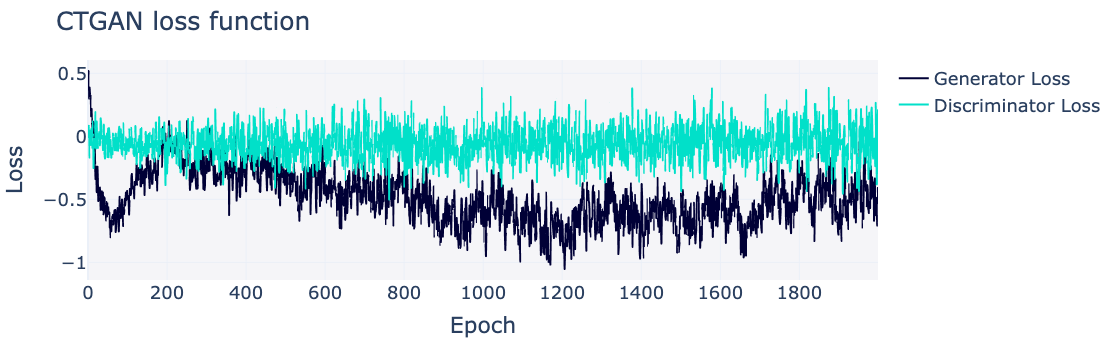

In [117]:
train_and_save_synthesizer(minority_train_data, 'ton-iot-gan-minority.pkl')

Load and Run GAN

In [120]:
from sdv.single_table import CTGANSynthesizer
import time

start_time = time.time()
loaded_synthesizer = CTGANSynthesizer.load(filepath='ton-iot-gan-minority.pkl')
end_time = time.time()

print(f"API call took {end_time - start_time:.4f} seconds")

API call took 0.0195 seconds


In [121]:
from sdv.sampling import Condition
import pandas as pd
import time

# Function to generate synthetic data and append to the CSV file
def generate_and_append_synthetic_data(csv_file, label, num_rows, synthesizer):
    # Load the existing CSV file
    df = pd.read_csv(csv_file)

    # Define the condition to generate synthetic data for the specified label
    condition = Condition(num_rows=num_rows, column_values={'type': label})
    start_time = time.time()
    # Generate synthetic data
    synthetic_data = synthesizer.sample_from_conditions(conditions=[condition])
    end_time = time.time()
    print(f"API call took {end_time - start_time:.4f} seconds")
    # Round all numeric columns to 2 decimal places
    synthetic_data = synthetic_data.round(2)

    # Concatenate the generated synthetic data with the original dataframe
    updated_df = pd.concat([df, synthetic_data], ignore_index=True)

    # Overwrite the original CSV file with the updated dataframe
    updated_df.to_csv(csv_file, index=False)

    print(f"Synthetic data for label '{label}' added to {csv_file}")

In [122]:
csv_file = 'Train_Test_IoT_Fridge.CSV'

In [123]:
generate_and_append_synthetic_data(csv_file, 'ransomware', 2000, loaded_synthesizer)

Sampling conditions: 100%|█████████████████████████████████████████| 2000/2000 [00:00<00:00, 19388.45it/s]

API call took 0.1160 seconds
Synthetic data for label 'ransomware' added to Train_Test_IoT_Fridge.CSV


In [124]:
generate_and_append_synthetic_data(csv_file, 'xss', 2000, loaded_synthesizer)

Sampling conditions: 100%|█████████████████████████████████████████| 2000/2000 [00:00<00:00, 22344.60it/s]

API call took 0.0923 seconds
Synthetic data for label 'xss' added to Train_Test_IoT_Fridge.CSV


In [125]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

def preprocess_iot_fridge_dataset(df):
    temp_condition_encoded = pd.get_dummies(df['temp_condition'], prefix='temp')
    df = pd.concat([df.drop(columns=['temp_condition']), temp_condition_encoded], axis=1)

    label_encoder = LabelEncoder()
    df['label_encoded'] = label_encoder.fit_transform(df['type'])

    X = df.drop(columns=['type', 'label', 'label_encoded'])
    y = df['label_encoded']

    return X, y, label_encoder


In [126]:
# Load the dataset
df = pd.read_csv('Train_Test_IoT_Fridge-original-time-seconds.csv')


In [127]:
X, y, label_encoder = preprocess_iot_fridge_dataset(df)
print("Number of records in X:", len(X))
print("Number of records in y:", len(y))
print("Number of classes in label_encoder:", len(label_encoder.classes_))

Number of records in X: 39944
Number of records in y: 39944
Number of classes in label_encoder: 7


In [128]:
print(X.head())

    time  fridge_temperature  temp_high  temp_high   temp_high    temp_low  \
0  69580                9.00       True       False        False     False   
1  69580                9.25       True       False        False     False   
2  69585               12.65       True       False        False     False   
3  69585                4.65      False       False        False      True   
4  69595               12.65       True       False        False     False   

   temp_low   temp_low    
0      False       False  
1      False       False  
2      False       False  
3      False       False  
4      False       False  


In [129]:
print("\nLabel Mapping:")
for label, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label}: {code}")


Label Mapping:
backdoor: 0
ddos: 1
injection: 2
normal: 3
password: 4
ransomware: 5
xss: 6


In [130]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from imblearn.metrics import geometric_mean_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def evaluate_classification_cv(model, model_name, X, y, label_encoder, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    y_pred = cross_val_predict(model, X, y, cv=skf)

    f1 = f1_score(y, y_pred, average='weighted')
    accuracy = accuracy_score(y, y_pred)
    g_mean = geometric_mean_score(y, y_pred, average='weighted')
    cm = confusion_matrix(y, y_pred)

    # Sensitivity & Specificity
    sensitivities = []
    specificities = []
    n_classes = len(np.unique(y))

    for i in range(n_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - tp - fn - fp

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        sensitivities.append(sensitivity)
        specificities.append(specificity)

    print(f"\n📊 Results for {model_name} (Stratified {folds}-Fold CV):")
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print(f"G-Mean         : {g_mean:.4f}")
    print(f"Avg Sensitivity: {np.mean(sensitivities):.4f}")
    print(f"Avg Specificity: {np.mean(specificities):.4f}")

    # Print confusion matrix as a clean table
    class_names = label_encoder.classes_
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    print("\n📋 Confusion Matrix:")
    print(cm_df)

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f"{model_name} - Confusion Matrix (CV)")
    plt.show()

    # Print classification report
    print("\n📝 Classification Report:")
    print(classification_report(y, y_pred, target_names=class_names))


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/opt/anaconda3/lib/python3.12/site-packa


📊 Results for Logistic Regression (Stratified 5-Fold CV):
Accuracy       : 0.6679
F1 Score       : 0.6523
G-Mean         : 0.8002
Avg Sensitivity: 0.5539
Avg Specificity: 0.9466

📋 Confusion Matrix:
            backdoor  ddos  injection  normal  password  ransomware   xss
backdoor         197  2044       1411       0       232         914   202
ddos             318  3062          0       0      1620           0     0
injection       1157     0       3842       0         0           0     1
normal             0    16          0   14984         0           0     0
password         854  2197          1       0      1948           0     0
ransomware         0     0         56       0         0        1562  1284
xss                0     0        107       0         0         852  1083


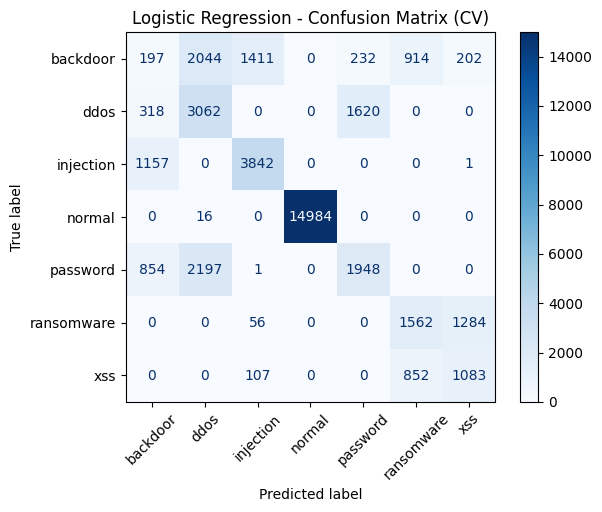


📝 Classification Report:
              precision    recall  f1-score   support

    backdoor       0.08      0.04      0.05      5000
        ddos       0.42      0.61      0.50      5000
   injection       0.71      0.77      0.74      5000
      normal       1.00      1.00      1.00     15000
    password       0.51      0.39      0.44      5000
  ransomware       0.47      0.54      0.50      2902
         xss       0.42      0.53      0.47      2042

    accuracy                           0.67     39944
   macro avg       0.52      0.55      0.53     39944
weighted avg       0.65      0.67      0.65     39944



In [131]:
from sklearn.linear_model import LogisticRegression
# Logistic Regression
evaluate_classification_cv(LogisticRegression(max_iter=5000, class_weight='balanced'),
                           "Logistic Regression", X, y, label_encoder)



📊 Results for Random Forest (Stratified 5-Fold CV):
Accuracy       : 0.8671
F1 Score       : 0.8669
G-Mean         : 0.9234
Avg Sensitivity: 0.8091
Avg Specificity: 0.9786

📋 Confusion Matrix:
            backdoor  ddos  injection  normal  password  ransomware   xss
backdoor        4473   189        337       0         1           0     0
ddos             210  3212          0       0      1578           0     0
injection        238     0       4762       0         0           0     0
normal             0     0          0   15000         0           0     0
password           0  1485          0       0      3515           0     0
ransomware         0     0          0       0         0        2255   647
xss                0     0          0       0         0         624  1418


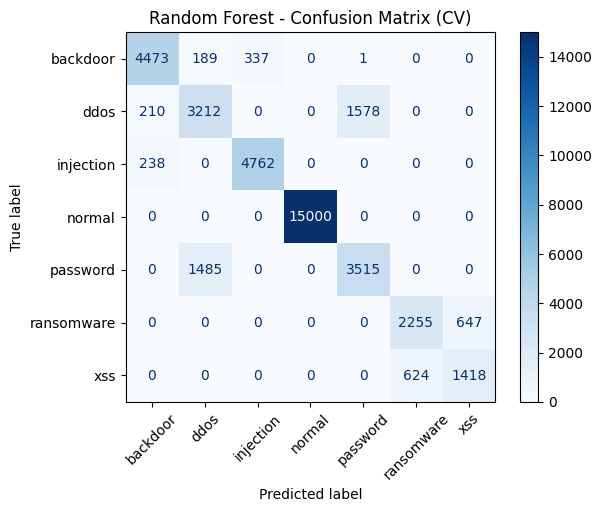


📝 Classification Report:
              precision    recall  f1-score   support

    backdoor       0.91      0.89      0.90      5000
        ddos       0.66      0.64      0.65      5000
   injection       0.93      0.95      0.94      5000
      normal       1.00      1.00      1.00     15000
    password       0.69      0.70      0.70      5000
  ransomware       0.78      0.78      0.78      2902
         xss       0.69      0.69      0.69      2042

    accuracy                           0.87     39944
   macro avg       0.81      0.81      0.81     39944
weighted avg       0.87      0.87      0.87     39944



In [132]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
evaluate_classification_cv(RandomForestClassifier(class_weight='balanced'),
                           "Random Forest", X, y, label_encoder)


📊 Results for Linear SVC (Stratified 5-Fold CV):
Accuracy       : 0.3032
F1 Score       : 0.2148
G-Mean         : 0.4757
Avg Sensitivity: 0.1827
Avg Specificity: 0.8642

📋 Confusion Matrix:
            backdoor  ddos  injection  normal  password  ransomware  xss
backdoor           0  2252          0    2592       156           0    0
ddos               0  3538          0    1462         0           0    0
injection          0  1240          0    3369       391           0    0
normal             0  6127          0    8573       300           0    0
password           0  3354          0    1646         0           0    0
ransomware         0   142          0    2569       191           0    0
xss                0   124          0    1771       147           0    0


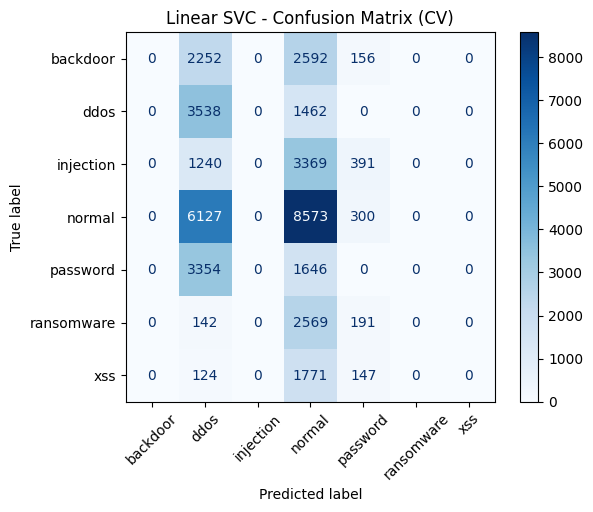


📝 Classification Report:
              precision    recall  f1-score   support

    backdoor       0.00      0.00      0.00      5000
        ddos       0.21      0.71      0.32      5000
   injection       0.00      0.00      0.00      5000
      normal       0.39      0.57      0.46     15000
    password       0.00      0.00      0.00      5000
  ransomware       0.00      0.00      0.00      2902
         xss       0.00      0.00      0.00      2042

    accuracy                           0.30     39944
   macro avg       0.09      0.18      0.11     39944
weighted avg       0.17      0.30      0.21     39944



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [133]:
from sklearn.svm import LinearSVC

# Linear SVC
evaluate_classification_cv(LinearSVC(max_iter=5000, class_weight='balanced'),
                           "Linear SVC", X, y, label_encoder)

In [135]:
# Load the augmented dataset
df_augmented = pd.read_csv('Train_Test_IoT_Fridge.csv')

In [136]:
X_a, y_a, label_encoder_a = preprocess_iot_fridge_dataset(df_augmented)
print("Number of records in X:", len(X_a))
print("Number of records in y:", len(y_a))
print("Number of classes in label_encoder:", len(label_encoder_a.classes_))

Number of records in X: 43944
Number of records in y: 43944
Number of classes in label_encoder: 7


In [137]:
print(X_a.head())

    time  fridge_temperature  temp_high  temp_high   temp_high    temp_low  \
0  69580                9.00       True       False        False     False   
1  69580                9.25       True       False        False     False   
2  69585               12.65       True       False        False     False   
3  69585                4.65      False       False        False      True   
4  69595               12.65       True       False        False     False   

   temp_low   temp_low    
0      False       False  
1      False       False  
2      False       False  
3      False       False  
4      False       False  


In [138]:
print("\nLabel Mapping:")
for label, code in zip(label_encoder_a.classes_, label_encoder_a.transform(label_encoder_a.classes_)):
    print(f"{label}: {code}")


Label Mapping:
backdoor: 0
ddos: 1
injection: 2
normal: 3
password: 4
ransomware: 5
xss: 6


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/opt/anaconda3/lib/python3.12/site-packa


📊 Results for Logistic Regression (Stratified 5-Fold CV):
Accuracy       : 0.6587
F1 Score       : 0.6439
G-Mean         : 0.7942
Avg Sensitivity: 0.5583
Avg Specificity: 0.9452

📋 Confusion Matrix:
            backdoor  ddos  injection  normal  password  ransomware   xss
backdoor         164  2040       1554       0       222         932    88
ddos             504  2818          0       0      1678           0     0
injection        983     0       4017       0         0           0     0
normal             0    36          0   14964         0           0     0
password        1095  2028          9       0      1868           0     0
ransomware         0     0         69       0         0        2956  1877
xss                0     0        188       0         0        1696  2158


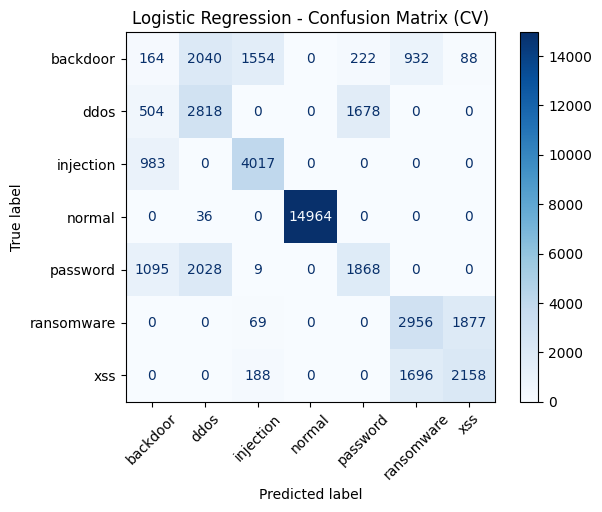


📝 Classification Report:
              precision    recall  f1-score   support

    backdoor       0.06      0.03      0.04      5000
        ddos       0.41      0.56      0.47      5000
   injection       0.69      0.80      0.74      5000
      normal       1.00      1.00      1.00     15000
    password       0.50      0.37      0.43      5000
  ransomware       0.53      0.60      0.56      4902
         xss       0.52      0.53      0.53      4042

    accuracy                           0.66     43944
   macro avg       0.53      0.56      0.54     43944
weighted avg       0.64      0.66      0.64     43944



In [139]:
from sklearn.linear_model import LogisticRegression
# Logistic Regression
evaluate_classification_cv(LogisticRegression(max_iter=5000, class_weight='balanced'),
                           "Logistic Regression", X_a, y_a, label_encoder_a)


📊 Results for Random Forest (Stratified 5-Fold CV):
Accuracy       : 0.8539
F1 Score       : 0.8537
G-Mean         : 0.9157
Avg Sensitivity: 0.8082
Avg Specificity: 0.9766

📋 Confusion Matrix:
            backdoor  ddos  injection  normal  password  ransomware   xss
backdoor        4467   188        341       0         4           0     0
ddos             214  3200          0       0      1586           0     0
injection        244     0       4756       0         0           0     0
normal             0     0          0   15000         0           0     0
password           0  1492          0       0      3508           0     0
ransomware         0     0          0       0         0        3675  1227
xss                0     0          0       0         0        1126  2916


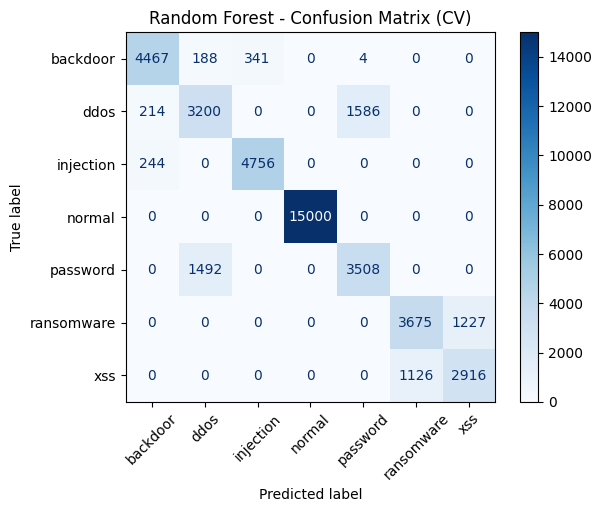


📝 Classification Report:
              precision    recall  f1-score   support

    backdoor       0.91      0.89      0.90      5000
        ddos       0.66      0.64      0.65      5000
   injection       0.93      0.95      0.94      5000
      normal       1.00      1.00      1.00     15000
    password       0.69      0.70      0.69      5000
  ransomware       0.77      0.75      0.76      4902
         xss       0.70      0.72      0.71      4042

    accuracy                           0.85     43944
   macro avg       0.81      0.81      0.81     43944
weighted avg       0.85      0.85      0.85     43944



In [140]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
evaluate_classification_cv(RandomForestClassifier(class_weight='balanced'),
                           "Random Forest", X_a, y_a, label_encoder_a)

In [ ]:
References to write the code:
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html
